# NLP classification - supervised learning

In this example, you will learn how you can use supervised learning algorithms for NLP classification. We will use documents from mtsamples again. The task is to classify a document into its clinical specialty, e.g. pediatrics or hematology.

We will use classification algorithms as implemented in sci-kit learn, and evaluate with cross-validation before testing on unseen test data.

We will experiment with different ways of representing the documents for the classifiers.

material in parts from https://towardsdatascience.com/multi-class-text-classification-with-scikit-learn-12f1e60e0a9f

Written by Sumithra Velupillai, March 2019 - updated February 2020; February 2025

# 1: Packages
We will use a number of different packages for this exercise

In [1]:
%matplotlib inline

import matplotlib
import matplotlib.pyplot as plt

import pandas as pd
try:
    import xlrd
except ImportError as e:
    !pip install xlrd
    import xlrd

import numpy as np

import warnings; warnings.simplefilter('ignore')


In [2]:
# We'll use scikit-learn for the classification algorithms.
# https://scikit-learn.org/stable/

#from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
#from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC


In [3]:
## sklearn also has some nice funtions for representations

from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

## and for evaluation
from sklearn.pipeline import Pipeline
from sklearn import metrics
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score



In [4]:
## Since we're working with text, we might need to tokenize for some of these representations.
# We'll use nltk here, but there are other nlp packages available for this
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords







[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [5]:
# You have also learnt about embedding representations. These can also be used for classification.
# We will use a library called Zeugma, which allows using pre-trained embedding models
#Zeugma library: https://github.com/nkthiebaut/zeugma

try:
    from zeugma.embeddings import EmbeddingTransformer
except ImportError as e:
    !pip install zeugma
    !pip install theano
    from zeugma.embeddings import EmbeddingTransformer

from datetime import datetime
print(datetime.now())

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 21.2 MB/s eta 0:00:00
  Created wheel for zeugma: filename=zeugma-0.49-py3-none-any.whl size=8791 sha256=2660fbd402db83bbc4b315500f6e06bac31d2eb6860d2b74d1fea04c5fe25ec2
  Stored in directory: /root/.cache/pip/wheels/cc/b5/14/aba5433859ce5edc62c8676f4864a4ffba6e1ebc06934f1f99
Successfully built zeugma
  Attempting uninstall: scipy
    Found existing installation: scipy 1.14.1
    Uninstalling scipy-1.14.1:
      Successfully uninstalled scipy-1.14.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 36.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for theano: filename=Theano-1.0.5-py3-none-any.whl size=2668112 sha256=2ced8bb07c0f26413aa9ea0299771f121a81850d546cbf144d993906fe842701
  Stored in direc

# 2: Corpus
Read in the training data.

In [6]:

xlds_training = 'https://github.com/KCL-Health-NLP/nlp_examples/blob/master/classification/classification_trainingdata.xlsx?raw=true'
trainingdata = pd.read_excel(xlds_training)



Take a look at the content of the training data. What are we trying to classify? What are the labels we want to try to learn? How many instances do we have?

In [7]:
trainingdata['label'].value_counts()

,count
label,
hematology,81
pediatrics,63
pain,56
psychiatrypsychology,48


What types of features do you think would be useful for the classification task? Where can we get them? Take a look at one or two of the documents. Can you guess which classification label these belong to?

In [8]:
trainingtxt_example = trainingdata['txt'].tolist()[0]
print(trainingtxt_example)

_x000D_
        _x000D_
        _x000D_
_x000D_
        _x000D_
        
REASON FOR CONSULTATION:
  Thrombocytopenia.


HISTORY OF PRESENT ILLNESS:
  Mrs. XXX is a 17-year-old lady who is going to be 18 in about 3 weeks.  She has been referred for the further evaluation of her thrombocytopenia.  This thrombocytopenia was detected on a routine blood test performed on the 10th of June 2006.  Her hemoglobin was 13.3 with white count of 11.8 at that time.  Her lymphocyte count was 6.7.  The patient, subsequently, had a CBC repeated on the 10th at Hospital where her hemoglobin was 12.4 with a platelet count of 26,000.  She had a repeat of her CBC again on the 12th of June 2006 with hemoglobin of 14, white count of 11.6 with an increase in the number of lymphocytes.  Platelet count was 38.  Her rapid strep screen was negative but the infectious mononucleosis screen is positive.  The patient had a normal platelet count prior too and she is being evaluated for this low platelet count.

The pat

In [9]:
trainingtxt_example = trainingdata['txt'].tolist()[231]
print(trainingtxt_example)

_x000D_
        _x000D_
        _x000D_
_x000D_
        _x000D_
        
CHIEF COMPLAINT:
  Head injury.


HISTORY: 
 This 16-year-old female presents to Children's Hospital via paramedic ambulance with a complaint at approximately 6 p.m. while she was at band practice using her flag device.  She struck herself in the head with the flag.  There was no loss of consciousness.  She did feel dizzy.  She complained of a headache.  She was able to walk.  She continued to participate in her flag practice.  She got dizzier.  She sat down for a while and walked and during the second period of walking, she had some episodes of diplopia, felt that she might faint and was assisted to the ground and was transported via paramedic ambulance to Children's Hospital for further evaluation.


PAST MEDICAL HISTORY: 
 Hypertension.


ALLERGIES:
  DENIED TO ME; HOWEVER, IT IS NOTED BEFORE SEVERAL ACCORDING TO MEDITECH.


CURRENT MEDICATIONS: 
 Enalapril.


PAST SURGICAL HISTORY: 
 She had some kind of an ab

# 3: Representation - BoW

The most common baseline feature representation for text classification tasks is to use the *bag-of-words* representation, in a document-term matrix. Let's build a simple one using raw counts and only keeping a maximum of 500 features. We can use the CountVectorizer function from sklearn, and tokenize using a function from nltk.

In [10]:
first_vectorizer = CountVectorizer(ngram_range=(1,1), stop_words=None,
                             tokenizer=word_tokenize, max_features=500)
first_vectorizer.fit(trainingdata['txt'].tolist())
first_fit_transformed_data = first_vectorizer.fit_transform(trainingdata['txt'])


We can now look at this transformed representation for an example document.

In [11]:
first_transformed_data = first_vectorizer.transform([trainingdata['txt'].tolist()[231]])
print (first_transformed_data)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 153 stored elements and shape (1, 500)>
  Coords	Values
  (0, 3)	3
  (0, 7)	29
  (0, 9)	55
  (0, 14)	1
  (0, 17)	1
  (0, 24)	1
  (0, 25)	22
  (0, 26)	1
  (0, 28)	7
  (0, 29)	8
  (0, 32)	2
  (0, 33)	2
  (0, 34)	1
  (0, 35)	1
  (0, 47)	2
  (0, 48)	1
  (0, 49)	1
  (0, 53)	2
  (0, 54)	15
  (0, 57)	1
  (0, 61)	1
  (0, 62)	1
  (0, 63)	5
  (0, 66)	1
  (0, 70)	5
  :	:
  (0, 414)	1
  (0, 424)	1
  (0, 426)	1
  (0, 427)	1
  (0, 429)	2
  (0, 433)	1
  (0, 436)	1
  (0, 437)	11
  (0, 441)	4
  (0, 443)	1
  (0, 444)	2
  (0, 453)	15
  (0, 464)	1
  (0, 468)	1
  (0, 472)	1
  (0, 474)	6
  (0, 476)	1
  (0, 478)	1
  (0, 484)	1
  (0, 485)	2
  (0, 487)	1
  (0, 490)	9
  (0, 491)	1
  (0, 492)	4
  (0, 495)	1


What word is represented by the different indices? Have a look at a few examples.

In [12]:
print (first_vectorizer.get_feature_names_out()[32])

abdomen


In [13]:
print(first_fit_transformed_data.shape)
print ('Amount of Non-Zero occurences: ', first_fit_transformed_data.nnz)

(248, 500)
Amount of Non-Zero occurences:  30502


# 4: Classification
Let's build a classifier with this feature representation. In text classification, many classification algorithms have been shown to work well. Sci-kit learn has implementations for many different types of classification algorithms - have a look at their website!

Let's try a K nearest neighbour classifier.


In [14]:
kneighbour_classifier = KNeighborsClassifier().fit(first_fit_transformed_data, trainingdata['label'])

We now have a trained model. But how do we know how well it works? Let's evaluate it on the test data.

In [15]:

xlds_test = 'https://github.com/KCL-Health-NLP/nlp_examples/blob/master/classification/classification_test_data.xlsx?raw=true'
testdata = pd.read_excel(xlds_test)



## We need to transform this data to the same representation
first_fit_transformed_testdata = first_vectorizer.transform(testdata['txt'])

In [16]:
first_fit_transformed_testdata
kneighbour_predicted = kneighbour_classifier.predict(first_fit_transformed_testdata)
kneighbour_predicted

array(['pediatrics', 'pain', 'pain', 'pain', 'pediatrics', 'hematology',
       'pediatrics', 'hematology', 'pediatrics', 'pain', 'hematology',
       'pediatrics', 'hematology', 'psychiatrypsychology', 'pain',
       'hematology', 'hematology', 'pain', 'pain', 'hematology',
       'pediatrics', 'pain', 'hematology', 'psychiatrypsychology',
       'pediatrics', 'hematology', 'hematology'], dtype=object)

Let's make a list of all the labels in our dataset to evaluate, and then run some standard evaluation metrics

In [17]:
labels = list(set(testdata['label']))
print(metrics.classification_report(testdata['label'], kneighbour_predicted, target_names=labels))



                      precision    recall  f1-score   support

psychiatrypsychology       0.60      0.67      0.63         9
                pain       0.75      1.00      0.86         6
          pediatrics       0.71      0.71      0.71         7
          hematology       1.00      0.40      0.57         5

            accuracy                           0.70        27
           macro avg       0.77      0.70      0.69        27
        weighted avg       0.74      0.70      0.69        27



What do you think about these results? There are probably ways of improving this, by changing the representation or maybe trying a different classifier model.
__There is one main problem though: we can't use this test data to try different configurations! Why?__

# 5: N-fold cross-validation

We can employ n-fold cross-validation on the training data to experiment with different representations, parameters, and classifiers.

There are also various metrics that can be used to evaluate classification results.


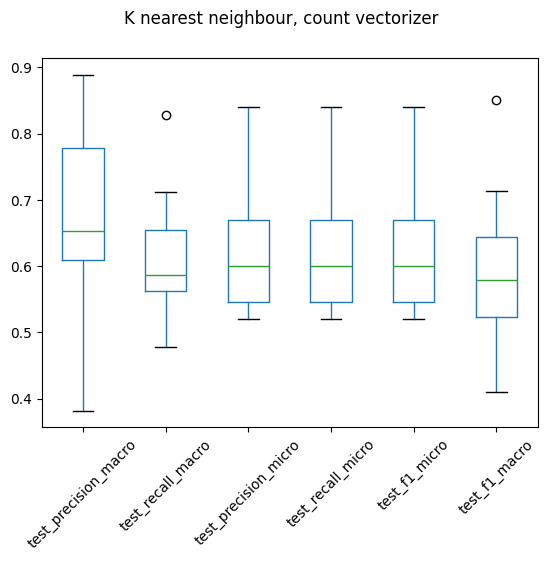

In [18]:
kneighbour_classifier = KNeighborsClassifier().fit(first_fit_transformed_data, trainingdata['label'])
scoring = ['precision_macro', 'recall_macro','precision_micro','recall_micro', 'f1_micro', 'f1_macro']
scores = cross_validate(kneighbour_classifier, first_fit_transformed_data, trainingdata['label'], scoring=scoring, cv=10, return_train_score=False)
scoresdf = pd.DataFrame(scores)
scoring = ['test_precision_macro', 'test_recall_macro','test_precision_micro','test_recall_micro', 'test_f1_micro', 'test_f1_macro']
bp = scoresdf.boxplot(column=scoring, grid=False, rot=45,)
[ax_tmp.set_xlabel('') for ax_tmp in np.asarray(bp).reshape(-1)]
fig = np.asarray(bp).reshape(-1)[0].get_figure()
fig.suptitle('K nearest neighbour, count vectorizer')
plt.show()

What happens if we try another classifier? Let's try a random forest classifier.

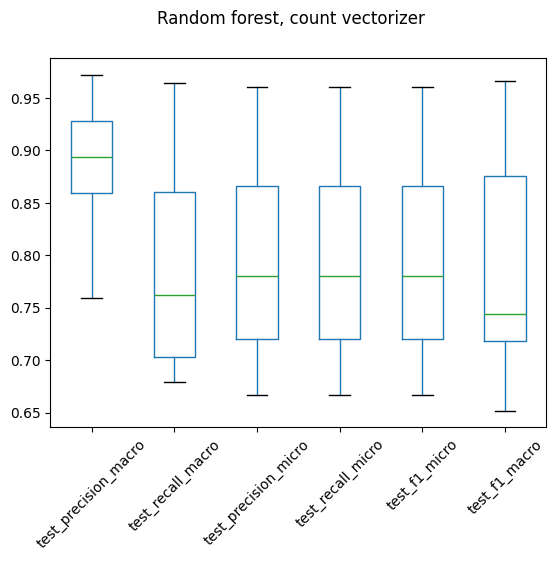

In [19]:
rf_classifier = RandomForestClassifier(n_estimators=200, max_depth=3, random_state=0).fit(first_fit_transformed_data, trainingdata['label'])
scoring = ['precision_macro', 'recall_macro','precision_micro','recall_micro', 'f1_micro', 'f1_macro']
scores = cross_validate(rf_classifier, first_fit_transformed_data, trainingdata['label'], scoring=scoring, cv=10, return_train_score=False)
scoresdf = pd.DataFrame(scores)
scoring = ['test_precision_macro', 'test_recall_macro','test_precision_micro','test_recall_micro', 'test_f1_micro', 'test_f1_macro']
bp = scoresdf.boxplot(column=scoring, grid=False, rot=45,)
[ax_tmp.set_xlabel('') for ax_tmp in np.asarray(bp).reshape(-1)]
fig = np.asarray(bp).reshape(-1)[0].get_figure()
fig.suptitle('Random forest, count vectorizer')
plt.show()

Was this better or worse? Are there any parameters worth changing?

# 6: Another representation model: Tf-idf
We have used a very simple bag-of-words representation. What happens if we try something else? Let's try tf-idf. This is considered a strong baseline in many text classification tasks.

In [20]:

stopWords = list(stopwords.words('english'))
tfidf_vect = TfidfVectorizer(tokenizer=word_tokenize, stop_words=stopWords)
tfidf_vect.fit(trainingdata['txt'])
second_fit_transformed_data =  tfidf_vect.transform(trainingdata['txt'])
second_fit_transformed_data

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 55597 stored elements and shape (248, 10455)>

What other parameters can you change in this representation? How does this look different from the CountVectorizer representation?

Let's now use this with the KNN classifier.

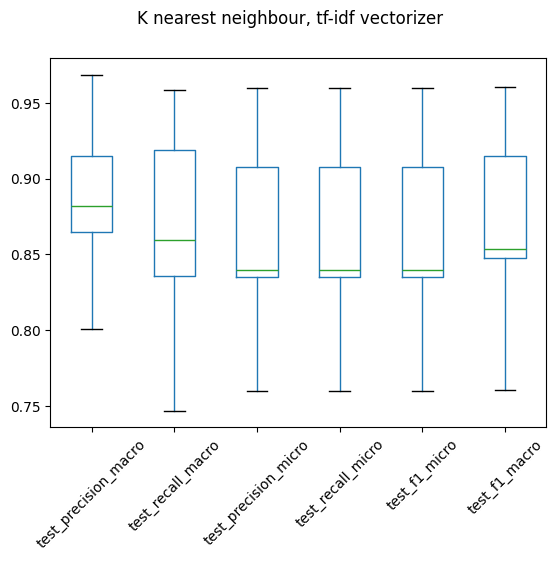

In [21]:
kneighbour_classifier = KNeighborsClassifier().fit(second_fit_transformed_data, trainingdata['label'])
scoring = ['precision_macro', 'recall_macro','precision_micro','recall_micro', 'f1_micro', 'f1_macro']
scores = cross_validate(kneighbour_classifier, second_fit_transformed_data, trainingdata['label'], scoring=scoring, cv=10, return_train_score=False)
scoresdf = pd.DataFrame(scores)
scoring = ['test_precision_macro', 'test_recall_macro','test_precision_micro','test_recall_micro', 'test_f1_micro', 'test_f1_macro']
bp = scoresdf.boxplot(column=scoring, grid=False, rot=45,)
[ax_tmp.set_xlabel('') for ax_tmp in np.asarray(bp).reshape(-1)]
fig = np.asarray(bp).reshape(-1)[0].get_figure()
fig.suptitle('K nearest neighbour, tf-idf vectorizer')
plt.show()

This looks better, doesn't it? Why do you think this works better?

# 7: Representations: embeddings

Last week, you learnt about embedding representations. What might be the benefit of using this type of representation instead of counts or tf-idf?

As you saw, there are many pre-trained embedding models available online. Let's try using one of these on this data.

Zeugma is a package where you can use embeddings in sklearn.
https://github.com/nkthiebaut/zeugma

It allows you to directly download pre-trained models that have been released from the gensim website.


Let's use a basic glove model.

In [22]:
glove = EmbeddingTransformer('glove')


[==================================================] 100.0% 104.8/104.8MB downloaded


We now need to transform our training data to map to this embedding model.

In [23]:
glove_transformed_training_data = glove.transform(trainingdata['txt'])

Have a look at what the data now looks like with this representation

In [24]:
glove_transformed_training_data

array([[-0.06901653,  0.23141852, -0.0103017 , ..., -0.00840962,
        -0.1129333 , -0.2936374 ],
       [-0.1314008 ,  0.22093552,  0.01704605, ...,  0.00743521,
        -0.09343443, -0.3224292 ],
       [-0.21260077,  0.22974722,  0.05217805, ..., -0.03708735,
        -0.02639649, -0.3227366 ],
       ...,
       [-0.17562525,  0.27378783,  0.04055113, ...,  0.10207053,
        -0.01623572, -0.32465863],
       [-0.34308803,  0.1576001 , -0.03746452, ...,  0.1564335 ,
        -0.14194974, -0.35664514],
       [-0.22268341,  0.14659327,  0.0234719 , ...,  0.02757135,
        -0.11957677, -0.35197183]], dtype=float32)

Let's build a classifier with this representation and evaluate with 10-fold cross-validation.

Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x78cc90fe9620>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 1175, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/ctypes/__init__.py", line 376, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: /usr/local/lib/python3.11/dist-packages/scipy.libs/libscipy_openblas-c128ec02.

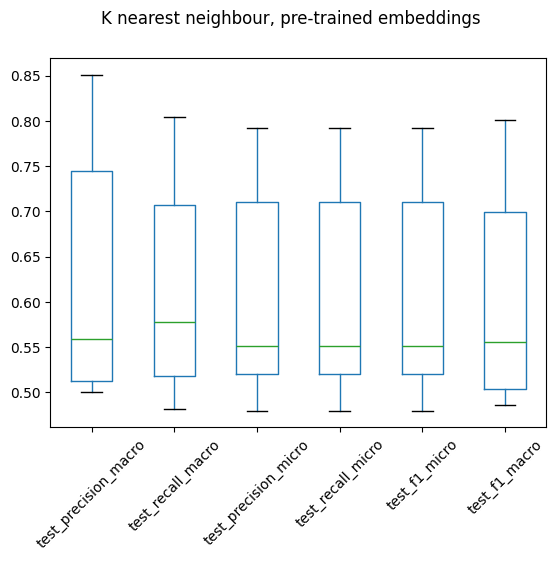

In [25]:
kneighbour_classifier = KNeighborsClassifier().fit(glove_transformed_training_data, trainingdata['label'])
scoring = ['precision_macro', 'recall_macro','precision_micro','recall_micro', 'f1_micro', 'f1_macro']
scores = cross_validate(kneighbour_classifier, glove_transformed_training_data, trainingdata['label'], scoring=scoring, cv=10, return_train_score=False)
scoresdf = pd.DataFrame(scores)
scoring = ['test_precision_macro', 'test_recall_macro','test_precision_micro','test_recall_micro', 'test_f1_micro', 'test_f1_macro']
bp = scoresdf.boxplot(column=scoring, grid=False, rot=45,)
[ax_tmp.set_xlabel('') for ax_tmp in np.asarray(bp).reshape(-1)]
fig = np.asarray(bp).reshape(-1)[0].get_figure()
fig.suptitle('K nearest neighbour, pre-trained embeddings')
plt.show()

What do you think about these results? What is happening here?

There are a number of pre-trained embedding models that have been released openly, a full list of pretrained embeddings to experiment with using this library: https://github.com/RaRe-Technologies/gensim-data#models

You can play with these if you want, e.g.:
glove = EmbeddingTransformer('glove-wiki-gigaword-50')

# 8: Classifiers, representations, evaluation

You've now seen that you get very different results depending on which representation you use, which classifier, and also that there are many different metrics to analyse.

Let's try some different configurations all in one go. We'll create a dictionary with the three different types of representations, and a list of different classification algorithms, and apply all these configurations to see what seems to yield best results according to a chosen evaluation metric using 10-fold cross validation.

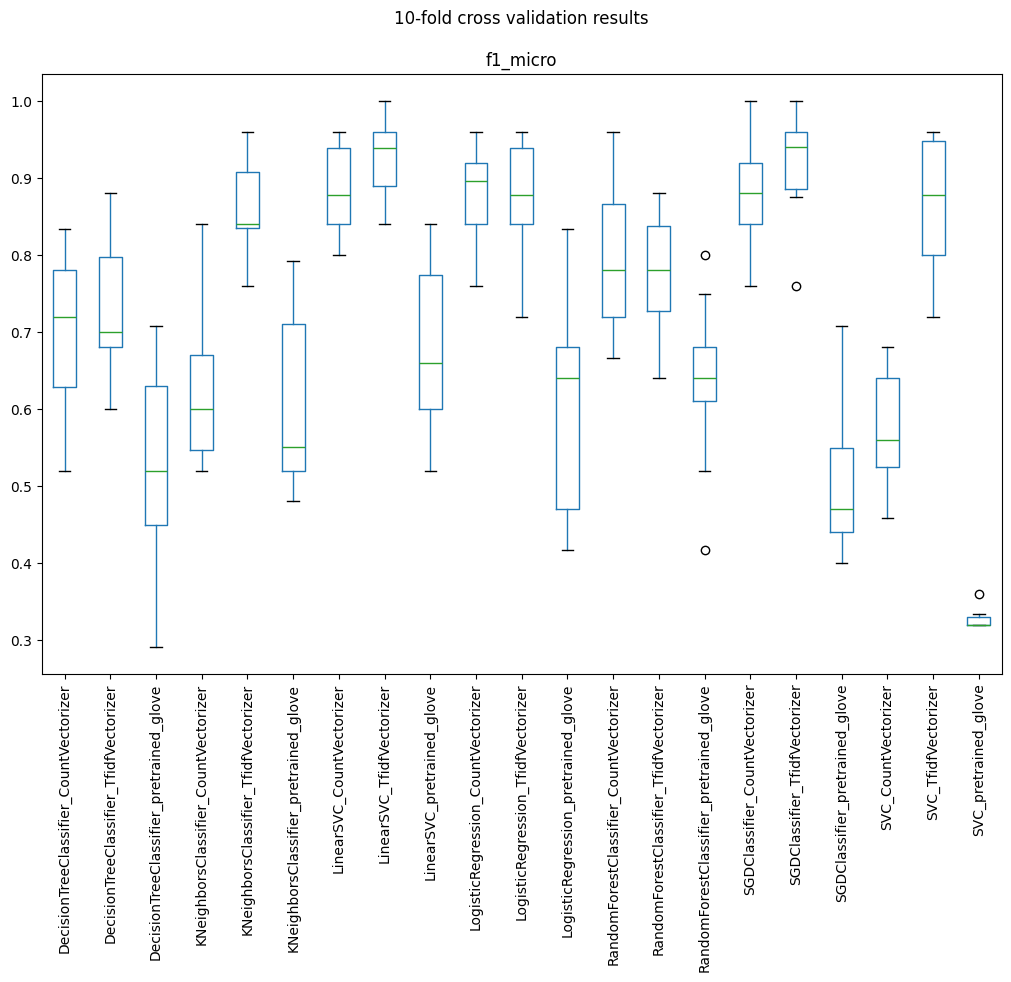

In [26]:

representations = {}

vectorizer = CountVectorizer(ngram_range=(1,1), stop_words=None,
                             tokenizer=word_tokenize, max_features=500)
xtrain_countvect = vectorizer.fit_transform(trainingdata['txt'])
representations['CountVectorizer'] = xtrain_countvect

tfidf_vect = TfidfVectorizer(tokenizer=word_tokenize, stop_words=stopWords)
tfidf_vect.fit(trainingdata['txt'])
xtrain_tfidf =  tfidf_vect.transform(trainingdata['txt'])
representations['TfidfVectorizer'] = xtrain_tfidf

x_train_glove = glove.transform(trainingdata['txt'])
representations['pretrained_glove'] = x_train_glove



CV = 10

classifier_models = [
        RandomForestClassifier(n_estimators=200, max_depth=3, random_state=0),
        DecisionTreeClassifier(),
        SVC(),
        LinearSVC(multi_class='ovr', C=1.0, class_weight=None, dual=True, fit_intercept=True,
     intercept_scaling=1, loss='squared_hinge', max_iter=1000,
      penalty='l2', random_state=0, tol=1e-05, verbose=0),
        SGDClassifier(),
        LogisticRegression(random_state=0),
        KNeighborsClassifier(),
]

cv_df = pd.DataFrame(index=range(CV * (len(classifier_models)*len(representations))))
entries = []


for representation, transformed_vector in representations.items():
    score = 'f1_micro'
    for model in classifier_models:
      model_name = model.__class__.__name__+'_'+representation
      accuracies = cross_val_score(model, transformed_vector, trainingdata['label'], scoring=score, cv=CV)
      for fold_idx, accuracy in enumerate(accuracies):
        entries.append((model_name, fold_idx, accuracy))
cv_df = pd.DataFrame(entries, columns=['model_name', 'fold_idx', score])
bp = cv_df.boxplot(by='model_name', column=[score], grid=False, rot=90, figsize=(12,8))
[ax_tmp.set_xlabel('') for ax_tmp in np.asarray(bp).reshape(-1)]
fig = np.asarray(bp).reshape(-1)[0].get_figure()
fig.suptitle('10-fold cross validation results')
plt.show()

What conclusions do you draw from this? Which classifier and which representation would you choose as your final model? Why?

# Assignment 1: Your turn to build a classifier

Answer questions by placing your code in the code cell below, running it to provide output, and giving your written answers in this markdown cell

**1.1 Choose one classifier and one representation format and test it on the blind test data. What do you think about your results, and how do they relate to the 10-fold cross validation results above?**

**1.2 What other configurations could you try before deciding on a final model?**

**1.3 Is it appropriate to experiment with this on the test data? Why or why not?**

In [30]:
## PUT YOUR CODE ANSWERS IN HERE, AND RUN IT TO GIVE OUTPUT
## First step: Transform your training and test data to your chosen representation.

## choose a representation: CountVectorizer or TfidfVectorizer, or embeddings

vectorizer = TfidfVectorizer()
## transform the training data
transformed_training_data = vectorizer.fit_transform(trainingdata['txt'])
## transform the test data
transformed_test_data = vectorizer.transform(testdata['txt'])


## Second step: Create a classifier - the one you think gave best results when experimenting with cross-validation

## train the classifier on the training data
classifier = LogisticRegression()
classifier.fit(transformed_training_data, trainingdata['label'])

## predict labels on the test data
predicted = classifier.predict(transformed_test_data)

unique_labels = sorted(set(trainingdata['label']))  # Get unique labels
target_names = [f"Class {label}" for label in unique_labels]  # Label names
## what results do you get?
print(metrics.classification_report(testdata['label'], predicted, target_names=target_names))

                            precision    recall  f1-score   support

          Class hematology       0.82      1.00      0.90         9
                Class pain       1.00      1.00      1.00         6
          Class pediatrics       1.00      0.71      0.83         7
Class psychiatrypsychology       1.00      1.00      1.00         5

                  accuracy                           0.93        27
                 macro avg       0.95      0.93      0.93        27
              weighted avg       0.94      0.93      0.92        27



Through the use of two models (embeddings cannot be replicated), it was found that TfidfVectorizer performs better than CountVectorizer in all classes. Therefore, TfidfVectorizer was chosen to complete the following tasks

# Assignment 2: use your classifier to predict labels on unseen text

Answer questions by placing your code in the three code cells below, running it to provide output, and giving your written answers in this markdown cell

**What happens if you try to predict a label with a completely new text using your chosen trained classifier model? Does it seem to classify correctly?**

In [31]:
new_text = 'Patient with severe depression.'

# Transform the new text (wrap in list)
transformed_new_text = vectorizer.transform([new_text])

# Predict the label
predicted_label = classifier.predict(transformed_new_text)

print(f"Predicted label for new text: {predicted_label[0]}")

Predicted label for new text: psychiatrypsychology


In [32]:
new_text = '5-year old girl with asthma.'

# Transform the new text (wrap in list)
transformed_new_text = vectorizer.transform([new_text])

# Predict the label
predicted_label = classifier.predict(transformed_new_text)

print(f"Predicted label for new text: {predicted_label[0]}")

Predicted label for new text: hematology


In [33]:
new_text = 'Her pain is severe.'

# Transform the new text (wrap in list)
transformed_new_text = vectorizer.transform([new_text])

# Predict the label
predicted_label = classifier.predict(transformed_new_text)

print(f"Predicted label for new text: {predicted_label[0]}")

Predicted label for new text: hematology


From the results, it appears that only one-third of the accuracy is achieved when we use the model with the highest accuracy. I think the model overfitting occurred during the training process. This indicates that although the model has 100% accuracy in paint and pediatrics, it is only familiar with the distribution of the training set and has not found any patterns

# Assignment 3: Evaluation

**Write ten example sentences or paragraphs where you assign the correct label to each of them. Then pass them to the classifier and calculate precision, recall and f-score, by completing the skeleton code in the cell below, and running it to give output. Analyse and discuss the results, giving your answer in this markdown cell.**

***Gold label values: psychiatrypsychology, hematology, pain, pediatrics***

In [39]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn import metrics

# 1. Training Data
train_text = [
    "The patient suffers from chronic migraine pain.",
    "Intense lower back pain can disrupt daily activities.",
    "The pediatric clinic specializes in child health care.",
    "Early detection of anemia is crucial in hematology.",
    "Cognitive therapy assists in managing depression effectively.",
    "Pediatricians ensure children meet growth milestones.",
    "Psychotherapy can treat various mental health disorders.",
    "Hematologists study blood diseases including leukemia.",
    "Pain management involves medications and therapy.",
    "Psychological disorders can affect daily functioning significantly."
]

train_labels = [
    'pain', 'pain', 'pediatrics', 'hematology', 'psychiatrypsychology',
    'pediatrics', 'psychiatrypsychology', 'hematology', 'pain', 'psychiatrypsychology'
]

# 2. Fit (train) the vectorizer first
chosen_representation = TfidfVectorizer()
trainX = chosen_representation.fit_transform(train_text)

# 3. Train the classifier next
chosen_classifier = MultinomialNB()
chosen_classifier.fit(trainX, train_labels)

# 4. New Test Data
new_text = [
    "The patient reported severe joint pain and stiffness, especially in the morning hours.",  # pain
    "Lower back pain worsens when standing up after prolonged sitting.",  # pain
    "Childhood vaccinations significantly reduce pediatric infections.",  # pediatrics
    "Hemoglobin levels decreased significantly, suggesting possible anemia.",  # hematology
    "Cognitive-behavioral therapy helps manage symptoms of anxiety effectively.",  # psychiatrypsychology
    "Children suffering from measles need immediate pediatric care to avoid complications.",  # pediatrics
    "Clinical depression treatment often involves psychotherapy and medication.",  # psychiatrypsychology
    "Elevated white blood cell count may indicate leukemia.",  # hematology
    "The patient was prescribed painkillers to manage chronic neuropathic pain.",  # pain
    "Psychological counseling effectively treats post-traumatic stress disorder."  # psychiatrypsychology
]

new_gold_labels = ['pain', 'pain', 'pediatrics', 'hematology', 'psychiatrypsychology',
                   'pediatrics', 'psychiatrypsychology', 'hematology', 'pain', 'psychiatrypsychology']

# 5. Transform Test Data
testX = chosen_representation.transform(new_text)

# 6. Predict labels
predicted = chosen_classifier.predict(testX)

# Display predictions
print("Predicted labels:", predicted)

# 7. Classification Metrics
print("\nClassification Report:")
print(metrics.classification_report(new_gold_labels, predicted, target_names=set(new_gold_labels)))


Predicted labels: ['pain' 'pain' 'psychiatrypsychology' 'psychiatrypsychology'
 'psychiatrypsychology' 'pain' 'pain' 'hematology' 'pain'
 'psychiatrypsychology']

Classification Report:
                      precision    recall  f1-score   support

psychiatrypsychology       1.00      0.50      0.67         2
                pain       0.60      1.00      0.75         3
          pediatrics       0.00      0.00      0.00         2
          hematology       0.50      0.67      0.57         3

            accuracy                           0.60        10
           macro avg       0.53      0.54      0.50        10
        weighted avg       0.53      0.60      0.53        10




The overall accuracy is 0.6, and there is still a lot of room for improvement compared to the model used normally.
Precision: 0.53
Recall: 0.60
F1-score: 0.53
After considering the sample size of each category comprehensively, the performance is also average, mainly due to the imbalance between categories.
This is mainly caused by the types of psychiatry and pediatrics, and reinforcement learning can be appropriately applied or the sample size in the training set can be increased.
The current model also lacks sufficient grasp of medical features, which is a key area that can be improved in future training




You've now experimented with different respresentations for text classification, different classification algorithms, and experimental setups.

There are many other alternative approaches available today.


For instance, there are pre-trained biomedical embeddings, trained on scientific literature, one example: https://www.aclweb.org/anthology/W16-2922.pdf
https://github.com/cambridgeltl/BioNLP-2016

There are also many online resources with additional examples and ideas, here's one example: https://towardsdatascience.com/text-classification-in-python-dd95d264c802